In [1]:
import math, pickle, random
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm
import pandas as pd

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

DATA_ROOT = Path("data")
ONTS = ["ec", "mf", "bp", "cc"]

from collections import defaultdict

# GO DAG
OBO_PATH = Path("data/go-basic.obo")

def parse_go_obo(obo_path):
    parents = defaultdict(set)
    children = defaultdict(set)

    current_id = None

    with open(obo_path, "r") as f:
        for line in f:
            line = line.strip()

            if line == "[Term]":
                current_id = None
                continue

            if line.startswith("id: GO:"):
                current_id = line.split("id: ")[1]

            elif line.startswith("is_a: GO:") and current_id:
                p = line.split("is_a: ")[1].split(" ! ")[0]
                parents[current_id].add(p)
                children[p].add(current_id)

    return parents, children

parents_all, children_all = parse_go_obo(OBO_PATH)
print("GO DAG loaded:", len(parents_all))

# config
BATCH = 64
EPOCHS = 256
PATIENCE = 5

TOPK_CAND = 128
TOPM_NEIGHBOR = 10
DETACH_TOPK = False

PROPAGATION_STEPS = 3
PROP_TAU = 0.05
BETA_RESIDUAL = 0.5

USE_TAIL_AWARE_LAMBDA = True
LAMBDA_BASE = 0.5

USE_CONSISTENCY_LOSS = False
LAMBDA_CONS = 1e-3

SAVE_TAG = f"tailgr_topk{TOPK_CAND}_topm{TOPM_NEIGHBOR}"

Device: cuda
GO DAG loaded: 43245


# 数据集

In [2]:
def load_ontology(ont):
    TERMS_PKL = DATA_ROOT / ont / "terms.pkl"
    TRAIN_PKL = DATA_ROOT / ont / "train_data.pkl"
    VALID_PKL = DATA_ROOT / ont / "valid_data.pkl"
    TEST_PKL  = DATA_ROOT / ont / "test_data.pkl"

    terms_df = pickle.load(open(TERMS_PKL, "rb"))
    terms = terms_df["gos"].tolist()
    K = len(terms)
    term2idx = {g:i for i, g in enumerate(terms)}

    def load_split(pkl):
        df = pickle.load(open(pkl, "rb"))
        X = torch.stack(df["esm2"].tolist()).float()
        Y = torch.zeros(len(df), K)

        for i, anns in enumerate(df["prop_annotations"]):
            for g in anns:
                if g in term2idx:
                    Y[i, term2idx[g]] = 1.0
        return df, X, Y

    train_df, Xtr, Ytr = load_split(TRAIN_PKL)
    valid_df, Xva, Yva = load_split(VALID_PKL)
    test_df,  Xte, Yte = load_split(TEST_PKL)

    return {
        "terms": terms,
        "K": K,
        "term2idx": term2idx,
        "train_df": train_df,
        "Xtr": Xtr, "Ytr": Ytr,
        "Xva": Xva, "Yva": Yva,
        "Xte": Xte, "Yte": Yte,
    }

In [3]:
def load_ec_dataset():
    data = torch.load("data/ec_dataset.pt")

    X = data["X"].float()
    Y = data["Y"].float()
    ec2idx = data["ec2idx"]

    K = Y.shape[1]
    terms = list(ec2idx.keys())
    term2idx = ec2idx

    # ===== split =====
    n = X.shape[0]
    n_train = int(0.8 * n)
    n_valid = int(0.1 * n)

    return {
        "terms": terms,
        "K": K,
        "term2idx": term2idx,
        "train_df": None,
        "Xtr": X[:n_train], "Ytr": Y[:n_train],
        "Xva": X[n_train:n_train+n_valid], "Yva": Y[n_train:n_train+n_valid],
        "Xte": X[n_train+n_valid:], "Yte": Y[n_train+n_valid:],
    }

In [4]:
import scipy.sparse as sp
from scipy.sparse.linalg import eigsh

def build_ec_graph(terms, term2idx):
    rows, cols = [], []

    for ec in terms:
        parts = ec.split(".")

        for i in range(1, len(parts)):
            parent = ".".join(parts[:i])

            if parent in term2idx:
                u = term2idx[ec]
                v = term2idx[parent]

                rows.append(u); cols.append(v)
                rows.append(v); cols.append(u)

    data = np.ones(len(rows))
    K = len(terms)

    A = sp.coo_matrix((data, (rows, cols)), shape=(K, K))
    return A

In [5]:
def load_go_emb(ont, K):
    path = Path(f"data/go_{ont}_directed_emb.npy")
    go_emb = torch.tensor(np.load(path), dtype=torch.float32)

    assert go_emb.shape[0] == K

    go_emb = go_emb.to(DEVICE)
    go_emb.requires_grad = False

    return go_emb

In [6]:
def build_dag_adj_matrix(terms, term2idx, parents_all, children_all):
    K = len(terms)
    A = torch.zeros(K, K)

    for g in terms:
        i = term2idx[g]

        # parent
        for p in parents_all.get(g, []):
            if p in term2idx:
                j = term2idx[p]
                A[i, j] = 1.0
                A[j, i] = 1.0

        # child（可选，但建议加）
        for c in children_all.get(g, []):
            if c in term2idx:
                j = term2idx[c]
                A[i, j] = 1.0
                A[j, i] = 1.0

    return A

In [7]:
def build_go_neighbors(go_emb, ont, topm=20):
    go_emb_norm = F.normalize(go_emb, dim=1)

    sim = go_emb_norm @ go_emb_norm.T
    sim.fill_diagonal_(-1e9)

    _, neigh_idx = torch.topk(sim, k=topm, dim=1)

    torch.save(neigh_idx.cpu(), f"go_neighbors_{ont}.pt")

In [8]:
import torch
from pathlib import Path

for ont in ["mf", "cc", "bp", "ec"]:
    path = Path(f"go_neighbors_{ont}.pt")

    need_build = True

    if path.exists():
        try:
            neigh = torch.load(path)
            if neigh.ndim == 2:
                need_build = False
                print(f"[OK] {ont} neighbors loaded")
            else:
                print(f"[WARN] {ont} file corrupted, rebuilding...")
        except:
            print(f"[ERROR] {ont} load failed, rebuilding...")

    if need_build:
        print(f"[BUILD] building neighbors for {ont}...")
        if ont == "ec":
            data = load_ec_dataset()
        else:
            data = load_ontology(ont)
        K = data["K"]
        if ont == "ec":
            ec_emb = np.load("data/ec_directed_spectral_emb.npy")
            go_emb = torch.tensor(ec_emb, dtype=torch.float32).to(DEVICE)
        else:
            go_emb = load_go_emb(ont, K)
        build_go_neighbors(go_emb, ont)

[OK] mf neighbors loaded
[OK] cc neighbors loaded
[OK] bp neighbors loaded
[OK] ec neighbors loaded


# 模型

In [9]:
class TAILGRModel(nn.Module):
    def __init__(self, K, go_emb, A_dag_full, ont, topk_cand=256, topm_neighbor=10, beta_residual=0.5, gamma=0.3):
        super().__init__()

        self.K = K
        self.ont = ont
        self.topk_cand = topk_cand
        self.topm_neighbor = topm_neighbor

        self.encoder = nn.Sequential(
            nn.Linear(5120, 2048),
            nn.ReLU(),
            nn.LayerNorm(2048)
        )

        self.classifier = nn.Linear(2048, K, bias=False)

        self.register_buffer("go_emb", go_emb)
        self.register_buffer("go_emb_norm", F.normalize(go_emb, dim=1))

        self.beta_residual = beta_residual

        self.register_buffer("A_dag_full", A_dag_full)
        self.gamma = gamma

        self.go_proj = nn.Linear(self.go_emb.shape[1], 2048)

        self.register_buffer(
            "go_neighbors",
            torch.load(f"go_neighbors_{ont}.pt")
        )

    def build_local_graph(self, cand_emb, topk_idx, cand_count):
        B, k, d = cand_emb.shape
    
        sim_cos = torch.bmm(cand_emb, cand_emb.transpose(1, 2))
    
        A_dag = self.A_dag_full[topk_idx]
        A_dag = torch.gather(
            A_dag,
            2,
            topk_idx.unsqueeze(1).expand(-1, k, -1)
        )
    
        mask = (A_dag > 0).float()
        sim = sim_cos * (0.2 + 0.8 * mask) + self.gamma * A_dag
    
        bias = torch.log(1.0 + cand_count.unsqueeze(2) * cand_count.unsqueeze(1))
    
        bias = bias / (bias.max(dim=-1, keepdim=True)[0] + 1e-8)
    
        sim = sim + 0.3 * bias
    
        eye = torch.eye(k, device=sim.device).unsqueeze(0)
        sim_no_self = sim.masked_fill(eye.bool(), -1e9)
    
        m = min(self.topm_neighbor, k - 1)
        topm_val, topm_idx = torch.topk(sim_no_self, k=m, dim=-1)
    
        A = torch.full_like(sim, -1e9)
        A.scatter_(2, topm_idx, topm_val)
    
        A = torch.where(eye.bool(), torch.zeros_like(A), A)
        A = torch.softmax(A / PROP_TAU, dim=-1)
    
        return A

    def forward(self, x, alpha_vec=None, return_parts=False, detach_topk=True):
        
        h = self.encoder(x)
    
        logits_tmp = self.classifier(h)
        topk_val_ctx, topk_idx_ctx = torch.topk(logits_tmp, k=128, dim=1)
    
        attn_topk = torch.sigmoid(topk_val_ctx)
        attn_topk = attn_topk / (attn_topk.sum(dim=1, keepdim=True) + 1e-8)
    
        go_emb_topk = self.go_emb_norm[topk_idx_ctx]
        go_context = torch.bmm(
            attn_topk.unsqueeze(1),
            go_emb_topk
        ).squeeze(1)
    
        go_context = self.go_proj(go_context)
        h = h + 0.5 * go_context
    
        logits_data = self.classifier(h)
    
        weights = torch.sigmoid(logits_data)
        noise = torch.randn_like(weights) * 0.01
        scores = weights + noise
        _, topk_idx = torch.topk(scores, k=self.topk_cand, dim=1)
    
        neigh_idx = self.go_neighbors[topk_idx]
    
        expanded_list = []
        count_list = []

        max_k = self.topk_cand * 2

        
        for i in range(x.size(0)):
            idx_raw = torch.cat([topk_idx[i], neigh_idx[i].reshape(-1)])
    
            uniq, counts = torch.unique(idx_raw, return_counts=True)
    
            uniq = uniq[:max_k]
            counts = counts[:max_k]
    
            expanded_list.append(uniq)
            count_list.append(counts)
    
        max_len = max(len(idx) for idx in expanded_list)
    
        expanded_idx = torch.stack([
            torch.cat([
                idx,
                idx.new_full((max_len - len(idx),), idx[0])
            ])
            for idx in expanded_list
        ])
    
        cand_count = torch.stack([
            torch.cat([
                c.float(),
                torch.zeros(max_len - len(c), device=c.device)
            ])
            for c in count_list
        ])
    
        cand_count = cand_count / (cand_count.max(dim=1, keepdim=True)[0] + 1e-8)
    
        topk_idx = expanded_idx
    
        cand_scores = torch.gather(logits_data, 1, topk_idx)
        cand_weights = torch.gather(weights, 1, topk_idx)
        cand_emb = self.go_emb_norm[topk_idx].contiguous()
    
        A = self.build_local_graph(cand_emb, topk_idx, cand_count)
    
        if alpha_vec is not None and USE_TAIL_AWARE_LAMBDA:
            cand_alpha = torch.gather(
                alpha_vec.expand(x.size(0), -1), 1, topk_idx
            )
    
            cand_alpha = cand_alpha / (cand_alpha.mean(dim=1, keepdim=True) + 1e-8)
            lam = LAMBDA_BASE * cand_alpha
            lam = torch.clamp(lam, 0.01, 1.0)
        else:
            cand_alpha = torch.ones_like(cand_scores)
            lam = torch.full_like(cand_scores, LAMBDA_BASE)
    
        s = cand_scores
    
        mean_alpha = cand_alpha.mean(dim=1, keepdim=True)
        tail_mask = (cand_alpha > mean_alpha).float()
    
        for _ in range(PROPAGATION_STEPS):
            neigh = torch.bmm(A, s.unsqueeze(-1)).squeeze(-1)
            delta = neigh - s
            s = s + tail_mask * lam * delta
    
        s = s * (0.5 + 0.5 * cand_weights)
    
        refined_scores = cand_scores + self.beta_residual * (s - cand_scores) * cand_weights
    
        delta_local = (s - cand_scores) * (0.5 + 0.5 * tail_mask)
    
        delta = torch.zeros_like(logits_data)
        delta.scatter_(1, topk_idx, delta_local)
    
        logits = logits_data + self.beta_residual * delta
    
        if return_parts:
            struct_delta = torch.zeros_like(logits_data)
            struct_delta.scatter_(1, topk_idx, refined_scores - cand_scores)
    
            graph_map = torch.zeros_like(logits_data)
            graph_map.scatter_(1, topk_idx, (refined_scores - cand_scores).abs())
    
            return {
                "logits": logits,
                "logits_data": logits_data,
                "cand_scores": cand_scores,
                "refined_scores": refined_scores,
                "struct_delta": struct_delta,
                "topk_idx": topk_idx,
                "graph_map": graph_map,
                "lambda": lam,
                "A": A,
            }
    
        return logits

# 验证指标

In [10]:
def fmax_official(probs, labels, thresholds=np.linspace(0, 1, 101)):
    label_sets = [set(np.where(labels[i] == 1)[0]) for i in range(labels.shape[0])]
    best = 0.0

    for t in thresholds:
        Ps, Rs = [], []

        for i in range(len(label_sets)):
            pred = set(np.where(probs[i] >= t)[0])
            true = label_sets[i]

            if not pred and not true:
                continue

            tp = len(pred & true)
            fp = len(pred - true)
            fn = len(true - pred)

            if tp + fp > 0:
                Ps.append(tp / (tp + fp))
            if tp + fn > 0:
                Rs.append(tp / (tp + fn))

        if Ps and Rs:
            P, R = np.mean(Ps), np.mean(Rs)
            if P + R > 0:
                best = max(best, 2 * P * R / (P + R))

    return best


In [11]:
def embedding_consistency_loss_from_logits(logits, go_emb_norm, topm_neighbor=10):

    probs = torch.sigmoid(logits)

    with torch.no_grad():
        sim = torch.matmul(go_emb_norm, go_emb_norm.T)
        sim.fill_diagonal_(-1e9)

        m = min(topm_neighbor, sim.size(1) - 1)
        topm_val, topm_idx = torch.topk(sim, k=m, dim=1)
        w = torch.softmax(topm_val / PROP_TAU, dim=1)

    nbr_probs = probs[:, topm_idx]
    p_i = probs.unsqueeze(-1)

    loss = ((p_i - nbr_probs) ** 2) * w.unsqueeze(0)
    return loss.mean()

# 诊断函数

In [12]:
def inspect_model_parts(model, xb, alpha_vec=None):
    model.eval()
    with torch.no_grad():
        out = model(xb, alpha_vec=alpha_vec, return_parts=True, detach_topk=DETACH_TOPK)

        logits_data = out["logits_data"]
        cand_scores = out["cand_scores"]
        refined_scores = out["refined_scores"]
        struct_delta = out["struct_delta"]
        topk_idx = out["topk_idx"]
        lam = out["lambda"]
        graph_map = out["graph_map"]
        A = out["A"]

        eps = 1e-8

        graph_max = graph_map.max(dim=1).values.mean().item()
        graph_top5 = torch.topk(
            graph_map, k=min(5, graph_map.size(1)), dim=1
        ).values.sum(dim=1).mean().item()
        graph_entropy = (-(graph_map + eps) * torch.log(graph_map + eps)).sum(dim=1).mean().item()
        graph_mass = graph_map.sum(dim=1).mean().item()

        unique_ratio = torch.unique(topk_idx).numel() / graph_map.size(1)

        stats = {
            "data_abs": logits_data.abs().mean().item(),
            "cand_abs": cand_scores.abs().mean().item(),
            "refined_abs": refined_scores.abs().mean().item(),
            "delta_abs": struct_delta.abs().mean().item(),
            "lambda_mean": lam.mean().item(),
            "lambda_min": lam.min().item(),
            "lambda_max": lam.max().item(),
            "graph_max_mean": graph_max,
            "graph_top5_mean": graph_top5,
            "graph_entropy": graph_entropy,
            "graph_mass": graph_mass,
            "candidate_unique_ratio": unique_ratio,
            "A_diag_mean": torch.diagonal(A, dim1=1, dim2=2).mean().item(),
        }

        return stats

# 训练

In [13]:
'''
def train_one_ontology(ont):
    print(f"\n===== Training {ont.upper()} =====")

    if ont == "ec":
        data = load_ec_dataset()
        K = data["K"]
        ec_emb = np.load("data/ec_directed_spectral_emb.npy")
        go_emb = torch.tensor(ec_emb, dtype=torch.float32).to(DEVICE)
    else:
        data = load_ontology(ont)
        K = data["K"]
        go_emb = load_go_emb(ont, K)

    terms = data["terms"]
    term2idx = data["term2idx"]
    if ont == "ec":
        A = build_ec_graph(terms, term2idx)
        A_dag_full = torch.tensor(A.toarray(), dtype=torch.float32).to(DEVICE)
    else:
        A_dag_full = build_dag_adj_matrix(
            terms,
            term2idx,
            parents_all,
            children_all
        ).to(DEVICE)
    
    model = TAILGRModel(
        K,
        go_emb,
        A_dag_full,
        ont,
        TOPK_CAND,
        TOPM_NEIGHBOR,
        BETA_RESIDUAL,
        gamma=0.3
    ).to(DEVICE)

    if ont == "ec":
        freq = data["Ytr"].sum(dim=0).to(DEVICE)
    
    else:
        train_df = data["train_df"]
    
        terms_count = {g: 0 for g in terms}
        for anns in train_df["prop_annotations"]:
            for g in anns:
                if g in term2idx:
                    terms_count[g] += 1
    
        freq = torch.tensor(
            [terms_count[g] for g in terms],
            dtype=torch.float32,
            device=DEVICE
        )
    
    alpha_vec = 1.0 / torch.sqrt(freq + 1.0)
    alpha_vec = alpha_vec / alpha_vec.mean()
    alpha_vec = alpha_vec.unsqueeze(0)

    optimizer = torch.optim.Adam(model.parameters(), lr=2e-4)

    Xtr, Ytr = data["Xtr"], data["Ytr"]
    Xva, Yva = data["Xva"], data["Yva"]

    best_f = 0.0
    best_state = None
    wait = PATIENCE

    for ep in range(EPOCHS):
        epoch_base = 0.0
        epoch_cons = 0.0
        epoch_loss = 0.0
        count = 0

        model.train()
        perm = torch.randperm(len(Xtr))
        num_batches = math.ceil(len(Xtr) / BATCH)

        pbar = tqdm(
            range(0, len(Xtr), BATCH),
            total=num_batches,
            desc=f"{ont.upper()} Epoch {ep}",
            leave=False
        )

        for i in pbar:
            idx = perm[i:i+BATCH]
            xb = Xtr[idx].to(DEVICE)
            yb = Ytr[idx].to(DEVICE)

            out = model(
                xb,
                alpha_vec=alpha_vec if USE_TAIL_AWARE_LAMBDA else None,
                return_parts=True,
                detach_topk=DETACH_TOPK
            )
            preds = out["logits"]
            cand = out["cand_scores"]
            refined = out["refined_scores"]
            topk_idx = out["topk_idx"]
            
            cand_weights = torch.sigmoid(cand)
            delta = (refined - cand) * cand_weights
            
            yb_cand = torch.gather(yb, 1, topk_idx)
            
            cand_alpha = torch.gather(alpha_vec.expand(xb.size(0), -1), 1, topk_idx)
            tail_mask = (cand_alpha > 1.0)
            
            pos_mask = (yb_cand > 0.5) & tail_mask
            neg_mask = (yb_cand <= 0.5) & tail_mask

            loss_select = torch.tensor(0.0, device=DEVICE)

            margin = 0.02
            
            if pos_mask.any():
                pos_loss = torch.relu(margin - delta[pos_mask])
                loss_select += pos_loss.mean()
            
            if neg_mask.any():
                neg_loss = torch.relu(delta[neg_mask] + margin)
                loss_select += 0.1 * neg_loss.mean()
            
            head_mask = ~tail_mask
            head_neg_mask = (yb_cand <= 0.5) & head_mask
            
            if head_neg_mask.any():
                head_loss = torch.relu(delta[head_neg_mask])
                loss_select += 1.0 * head_loss.mean()
            
            base_loss = F.binary_cross_entropy_with_logits(preds, yb)
            
            LAMBDA_SELECT = 0.05
            # loss = base_loss + LAMBDA_SELECT * loss_select
            loss = base_loss
            cons_loss = torch.tensor(0.0, device=DEVICE)
            
            epoch_base += base_loss.item()
            epoch_cons += cons_loss.item()
            epoch_loss += loss.item()
            count += 1

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            pbar.set_postfix({
                "loss": f"{loss.item():.3f}",
                "base": f"{base_loss.item():.3f}",
                "cons": f"{cons_loss.item():.3f}"
            })

        # ===== validation =====
        model.eval()
        with torch.no_grad():
            
            probs_va = torch.zeros(len(Xva), K)
            with torch.no_grad():
                for i in range(0, len(Xva), 64):
                    xb = Xva[i:i+64].to(DEVICE)
                    logits = model(
                        xb,
                        alpha_vec=alpha_vec if USE_TAIL_AWARE_LAMBDA else None,
                        detach_topk=DETACH_TOPK
                    )
                    probs = torch.sigmoid(logits).cpu()
                    probs_va[i:i+len(probs)] = probs

                    del xb, logits, probs
                    torch.cuda.synchronize()
                    torch.cuda.empty_cache()
                    
            probs_va = probs_va.numpy()

        f_va = fmax_official(probs_va, Yva.numpy())

        inspect_x = Xva[:64].to(DEVICE)
        stats = inspect_model_parts(
            model,
            inspect_x,
            alpha_vec=alpha_vec if USE_TAIL_AWARE_LAMBDA else None
        )

        print(
            f"{ont} Epoch {ep} | "
            f"Loss={epoch_loss/count:.4f} "
            f"Base={epoch_base/count:.4f} "
            f"Cons={epoch_cons/count:.4f} "
            f"Fmax={f_va:.4f} | "
            f"data_abs={stats['data_abs']:.4f} "
            f"cand_abs={stats['cand_abs']:.4f} "
            f"refined_abs={stats['refined_abs']:.4f} "
            f"delta_abs={stats['delta_abs']:.4f} "
            f"lambda_mean={stats['lambda_mean']:.4f} "
            f"lambda_max={stats['lambda_max']:.4f} "
            f"A_diag={stats['A_diag_mean']:.4f} "
            f"graph_max={stats['graph_max_mean']:.4f} "
            f"graph_top5={stats['graph_top5_mean']:.4f} "
            f"graph_ent={stats['graph_entropy']:.2f} "
            f"uniq={stats['candidate_unique_ratio']:.4f}"
        )

        if f_va > best_f:
            best_f = f_va
            best_state = {k: v.cpu() for k, v in model.state_dict().items()}
            wait = PATIENCE
        else:
            wait -= 1
            if wait == 0:
                print("Early stopping")
                break

    return best_state, model, data, alpha_vec
'''
def train_one_ontology(ont):
    print(f"\n===== Training {ont.upper()} =====")

    if ont == "ec":
        data = load_ec_dataset()
        K = data["K"]
        ec_emb = np.load("data/ec_directed_spectral_emb.npy")
        go_emb = torch.tensor(ec_emb, dtype=torch.float32).to(DEVICE)
    else:
        data = load_ontology(ont)
        K = data["K"]
        go_emb = load_go_emb(ont, K)

    terms = data["terms"]
    term2idx = data["term2idx"]

    if ont == "ec":
        A = build_ec_graph(terms, term2idx)
        A_dag_full = torch.tensor(A.toarray(), dtype=torch.float32).to(DEVICE)
    else:
        A_dag_full = build_dag_adj_matrix(
            terms,
            term2idx,
            parents_all,
            children_all
        ).to(DEVICE)

    model = TAILGRModel(
        K,
        go_emb,
        A_dag_full,
        ont,
        TOPK_CAND,
        TOPM_NEIGHBOR,
        BETA_RESIDUAL,
        gamma=0.3
    ).to(DEVICE)

    if ont == "ec":
        freq = data["Ytr"].sum(dim=0).to(DEVICE)
    else:
        train_df = data["train_df"]

        terms_count = {g: 0 for g in terms}
        for anns in train_df["prop_annotations"]:
            for g in anns:
                if g in term2idx:
                    terms_count[g] += 1

        freq = torch.tensor(
            [terms_count[g] for g in terms],
            dtype=torch.float32,
            device=DEVICE
        )

    alpha_vec = 1.0 / torch.sqrt(freq + 1.0)
    alpha_vec = alpha_vec / alpha_vec.mean()
    alpha_vec = alpha_vec.unsqueeze(0)

    optimizer = torch.optim.Adam(model.parameters(), lr=2e-4)

    Xtr, Ytr = data["Xtr"], data["Ytr"]
    Xva, Yva = data["Xva"], data["Yva"]

    best_f = 0.0
    best_state = None
    wait = PATIENCE

    for ep in range(EPOCHS):
        epoch_loss = 0.0
        count = 0

        model.train()
        perm = torch.randperm(len(Xtr))
        num_batches = math.ceil(len(Xtr) / BATCH)

        pbar = tqdm(
            range(0, len(Xtr), BATCH),
            total=num_batches,
            desc=f"{ont.upper()} Epoch {ep}",
            leave=False
        )

        for i in pbar:
            idx = perm[i:i+BATCH]
            xb = Xtr[idx].to(DEVICE)
            yb = Ytr[idx].to(DEVICE)

            out = model(
                xb,
                alpha_vec=alpha_vec if USE_TAIL_AWARE_LAMBDA else None,
                return_parts=True,
                detach_topk=DETACH_TOPK
            )

            preds = out["logits"]

            loss = F.binary_cross_entropy_with_logits(preds, yb)

            epoch_loss += loss.item()
            count += 1

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            pbar.set_postfix({
                "loss": f"{loss.item():.3f}"
            })

        # ===== validation =====
        model.eval()
        with torch.no_grad():
            probs_va = torch.zeros(len(Xva), K)

            for i in range(0, len(Xva), 64):
                xb = Xva[i:i+64].to(DEVICE)

                logits = model(
                    xb,
                    alpha_vec=alpha_vec if USE_TAIL_AWARE_LAMBDA else None,
                    detach_topk=DETACH_TOPK
                )

                probs = torch.sigmoid(logits).cpu()
                probs_va[i:i+len(probs)] = probs

                del xb, logits, probs
                torch.cuda.synchronize()
                torch.cuda.empty_cache()

            probs_va = probs_va.numpy()

        f_va = fmax_official(probs_va, Yva.numpy())

        inspect_x = Xva[:64].to(DEVICE)
        stats = inspect_model_parts(
            model,
            inspect_x,
            alpha_vec=alpha_vec if USE_TAIL_AWARE_LAMBDA else None
        )

        print(
            f"{ont} Epoch {ep} | "
            f"Loss={epoch_loss/count:.4f} "
            f"Fmax={f_va:.4f} | "
            f"data_abs={stats['data_abs']:.4f} "
            f"cand_abs={stats['cand_abs']:.4f} "
            f"refined_abs={stats['refined_abs']:.4f} "
            f"delta_abs={stats['delta_abs']:.4f} "
            f"lambda_mean={stats['lambda_mean']:.4f} "
            f"lambda_max={stats['lambda_max']:.4f} "
            f"A_diag={stats['A_diag_mean']:.4f} "
            f"graph_max={stats['graph_max_mean']:.4f} "
            f"graph_top5={stats['graph_top5_mean']:.4f} "
            f"graph_ent={stats['graph_entropy']:.2f} "
            f"uniq={stats['candidate_unique_ratio']:.4f}"
        )

        if f_va > best_f:
            best_f = f_va
            best_state = {k: v.cpu() for k, v in model.state_dict().items()}
            wait = PATIENCE
        else:
            wait -= 1
            if wait == 0:
                print("Early stopping")
                break

    return best_state, model, data, alpha_vec

In [14]:
RESULTS = {}
MODELS = {}
ALPHAS = {}
DATASETS = {}

for ont in ONTS:
    best_state, model, data, alpha_vec = train_one_ontology(ont)

    model.load_state_dict(best_state)
    model.eval()

    MODELS[ont] = model
    ALPHAS[ont] = alpha_vec
    DATASETS[ont] = data

    Xte = data["Xte"]

    with torch.no_grad():
        preds = torch.sigmoid(
            torch.cat([
                model(
                    Xte[i:i+64].to(DEVICE),
                    alpha_vec=alpha_vec if USE_TAIL_AWARE_LAMBDA else None,
                    detach_topk=DETACH_TOPK
                )
                for i in range(0, len(Xte), 64)
            ])
        ).cpu().numpy()

    RESULTS[ont] = preds
    print(f"{ont} DONE | shape={preds.shape}")


===== Training EC =====


ec Epoch 0 | Loss=0.0414 Fmax=0.3309 | data_abs=6.7784 cand_abs=7.4361 refined_abs=7.4344 delta_abs=0.0002 lambda_mean=0.5000 lambda_max=0.8852 A_diag=0.0000 graph_max=0.0290 graph_top5=0.1004 graph_ent=2.65 uniq=0.3421


ec Epoch 1 | Loss=0.0090 Fmax=0.4040 | data_abs=7.2908 cand_abs=8.4242 refined_abs=8.4228 delta_abs=0.0002 lambda_mean=0.5000 lambda_max=0.8892 A_diag=0.0000 graph_max=0.0512 graph_top5=0.1245 graph_ent=1.91 uniq=0.3304


ec Epoch 2 | Loss=0.0079 Fmax=0.4370 | data_abs=7.5992 cand_abs=8.9536 refined_abs=8.9525 delta_abs=0.0001 lambda_mean=0.5000 lambda_max=0.8889 A_diag=0.0000 graph_max=0.0444 graph_top5=0.1087 graph_ent=1.60 uniq=0.3092


ec Epoch 3 | Loss=0.0069 Fmax=0.4783 | data_abs=7.7860 cand_abs=9.3794 refined_abs=9.3784 delta_abs=0.0001 lambda_mean=0.5000 lambda_max=0.8880 A_diag=0.0000 graph_max=0.0406 graph_top5=0.1050 graph_ent=1.43 uniq=0.3130


...

cc Epoch 7 | Loss=0.0067 Fmax=0.6867 | data_abs=11.8053 cand_abs=14.0809 refined_abs=14.0809 delta_abs=0.0000 lambda_mean=0.5000 lambda_max=0.7429 A_diag=0.0002 graph_max=0.0006 graph_top5=0.0015 graph_ent=0.03 uniq=0.1849


cc Epoch 8 | Loss=0.0064 Fmax=0.6833 | data_abs=12.1109 cand_abs=14.3627 refined_abs=14.3627 delta_abs=0.0000 lambda_mean=0.5000 lambda_max=0.7515 A_diag=0.0002 graph_max=0.0009 graph_top5=0.0020 graph_ent=0.03 uniq=0.1943


cc Epoch 9 | Loss=0.0061 Fmax=0.6854 | data_abs=12.7542 cand_abs=15.1939 refined_abs=15.1939 delta_abs=0.0000 lambda_mean=0.5000 lambda_max=0.7445 A_diag=0.0002 graph_max=0.0009 graph_top5=0.0018 graph_ent=0.02 uniq=0.1932


cc Epoch 10 | Loss=0.0059 Fmax=0.6837 | data_abs=13.0979 cand_abs=15.5754 refined_abs=15.5754 delta_abs=0.0000 lambda_mean=0.5000 lambda_max=0.7423 A_diag=0.0002 graph_max=0.0008 graph_top5=0.0018 graph_ent=0.02 uniq=0.1835


cc Epoch 11 | Loss=0.0056 Fmax=0.6836 | data_abs=13.5216 cand_abs=16.1732 refined_abs=16.1732 delta_abs=0.0000 lambda_mean=0.5000 lambda_max=0.7423 A_diag=0.0002 graph_max=0.0006 graph_top5=0.0013 graph_ent=0.02 uniq=0.1960
Early stopping
cc DONE | shape=(3565, 2888)


In [15]:
from pathlib import Path
Path("predict_result").mkdir(exist_ok=True)

for ont in ONTS:
    preds = RESULTS[ont]
    d = DATASETS[ont]

    df_pred = pd.DataFrame(preds)

    df_pred.columns = d["terms"]
    df_pred.insert(0, "protein_id", np.arange(len(df_pred)))

    save_path = f"predict_result/{ont}_{SAVE_TAG}.csv"
    df_pred.to_csv(save_path, index=False)

    print(f"Saved: {save_path}")

Saved: predict_result/ec_tailgr_topk128_topm10.csv
Saved: predict_result/mf_tailgr_topk128_topm10.csv
Saved: predict_result/bp_tailgr_topk128_topm10.csv
Saved: predict_result/cc_tailgr_topk128_topm10.csv


In [16]:
data = load_ec_dataset()
K = data["K"]

neigh = torch.load("go_neighbors_ec.pt").long()

print("===== CHECK go_neighbors_ec.pt =====")
print("EC K:", K)
print("neighbor shape:", neigh.shape)
print("neighbor min:", neigh.min().item())
print("neighbor max:", neigh.max().item())

print("shape[0] == K:", neigh.shape[0] == K)
print("min >= 0:", neigh.min().item() >= 0)
print("max < K:", neigh.max().item() < K)

data = torch.load("data/ec_dataset.pt")

X = data["X"]
Y = data["Y"]
ec2idx = data["ec2idx"]

print("===== ec_dataset.pt =====")
print("X shape:", X.shape)
print("Y shape:", Y.shape)
print("len(ec2idx):", len(ec2idx))
print("first 20 EC terms:", list(ec2idx.keys())[:20])
print("last 20 EC terms:", list(ec2idx.keys())[-20:])

print("Y label count:", Y.shape[1])
print("ec2idx count:", len(ec2idx))
print("Y.shape[1] == len(ec2idx):", Y.shape[1] == len(ec2idx))

ec_emb = np.load("data/ec_directed_spectral_emb.npy")

print("===== ec_directed_spectral_emb.npy =====")
print("ec_emb shape:", ec_emb.shape)

print("dataset K:", Y.shape[1])
print("emb rows == dataset K:", ec_emb.shape[0] == Y.shape[1])

===== CHECK go_neighbors_ec.pt =====
EC K: 2131
neighbor shape: torch.Size([2131, 20])
neighbor min: 0
neighbor max: 2130
shape[0] == K: True
min >= 0: True
max < K: True
===== ec_dataset.pt =====
X shape: torch.Size([7949, 5120])
Y shape: torch.Size([7949, 2131])
len(ec2idx): 2131
first 20 EC terms: ['1', '1.1', '1.1.1', '1.1.1.1', '1.1.1.100', '1.1.1.101', '1.1.1.102', '1.1.1.107', '1.1.1.116', '1.1.1.117', '1.1.1.12', '1.1.1.130', '1.1.1.145', '1.1.1.149', '1.1.1.153', '1.1.1.156', '1.1.1.169', '1.1.1.17', '1.1.1.170', '1.1.1.173']
last 20 EC terms: ['7.2', '7.2.2', '7.2.2.10', '7.2.2.12', '7.2.2.13', '7.2.2.21', '7.2.2.8', '7.2.2.9', '7.3', '7.3.2', '7.3.2.7', '7.4', '7.4.2', '7.4.2.7', '7.6', '7.6.2', '7.6.2.1', '7.6.2.2', '7.6.2.4', '7.6.2.9']
Y label count: 2131
ec2idx count: 2131
Y.shape[1] == len(ec2idx): True
===== ec_directed_spectral_emb.npy =====
ec_emb shape: (2131, 64)
dataset K: 2131
emb rows == dataset K: True


# DAG Embedding分析

In [17]:
from collections import defaultdict, deque
import math
import numpy as np
import torch
import pandas as pd
from pathlib import Path

OBO_PATH = Path("data/go-basic.obo")

In [18]:
def parse_go_obo(obo_path):
    parents = defaultdict(set)
    children = defaultdict(set)
    namespace = {}
    name_map = {}

    current_id = None
    current_name = None
    current_namespace = None
    is_obsolete = False

    with open(obo_path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()

            if line == "[Term]":
                current_id = None
                current_name = None
                current_namespace = None
                is_obsolete = False
                continue

            if not line:
                if current_id is not None and not is_obsolete:
                    name_map[current_id] = current_name
                    namespace[current_id] = current_namespace
                continue

            if line.startswith("id: GO:"):
                current_id = line.split("id: ")[1]

            elif line.startswith("name:"):
                current_name = line.split("name: ", 1)[1]

            elif line.startswith("namespace:"):
                current_namespace = line.split("namespace: ", 1)[1]

            elif line.startswith("is_obsolete: true"):
                is_obsolete = True

            elif line.startswith("is_a: GO:") and current_id is not None:
                p = line.split("is_a: ")[1].split(" ! ")[0]
                parents[current_id].add(p)
                children[p].add(current_id)

    return parents, children, namespace, name_map

parents_all, children_all, namespace_all, name_map_all = parse_go_obo(OBO_PATH)
print("Parsed GO terms:", len(name_map_all))

Parsed GO terms: 43248


In [19]:
ONT = "cc"   # "mf" / "bp" / "cc"

data = load_ontology(ONT)
terms = data["terms"]
K = data["K"]

go_emb = load_go_emb(ONT, K)
if isinstance(go_emb, tuple):
    go_emb = go_emb[0]

term_set = set(terms)

parents = {g: set(p for p in parents_all.get(g, set()) if p in term_set) for g in terms}
children = {g: set(c for c in children_all.get(g, set()) if c in term_set) for g in terms}

term2idx = {g: i for i, g in enumerate(terms)}
idx2term = {i: g for g, i in term2idx.items()}

print("Ontology:", ONT)
print("K =", K)
print("Embedding shape =", tuple(go_emb.shape))
print("Num nodes with parents in subgraph =", sum(len(parents[g]) > 0 for g in terms))

Ontology: cc
K = 2888
Embedding shape = (2888, 64)
Num nodes with parents in subgraph = 2885


In [20]:
def embedding_basic_stats(go_emb):
    emb = go_emb.detach().cpu()
    norms = emb.norm(dim=1).numpy()

    sim = torch.matmul(
        torch.nn.functional.normalize(emb, dim=1),
        torch.nn.functional.normalize(emb, dim=1).T
    )
    sim_np = sim.numpy()

    upper = sim_np[np.triu_indices(sim_np.shape[0], k=1)]

    stats = {
        "norm_mean": norms.mean(),
        "norm_std": norms.std(),
        "norm_min": norms.min(),
        "norm_max": norms.max(),
        "pairwise_cos_mean": upper.mean(),
        "pairwise_cos_std": upper.std(),
        "pairwise_cos_min": upper.min(),
        "pairwise_cos_max": upper.max(),
    }
    return pd.DataFrame([stats])

embedding_basic_stats(go_emb)

,norm_mean,norm_std,norm_min,norm_max,pairwise_cos_mean,pairwise_cos_std,pairwise_cos_min,pairwise_cos_max
0,0.037468,0.144072,2.357899e-09,0.991913,0.157798,0.229754,-0.893644,1.0


In [21]:
def sample_edge_and_random_pairs(terms, parents, term2idx, n_samples=20000, seed=42):
    rng = np.random.default_rng(seed)

    edge_pairs = []
    for child in terms:
        for p in parents[child]:
            edge_pairs.append((term2idx[child], term2idx[p]))

    if len(edge_pairs) > n_samples:
        chosen = rng.choice(len(edge_pairs), size=n_samples, replace=False)
        edge_pairs = [edge_pairs[i] for i in chosen]

    rand_pairs = []
    K = len(terms)
    edge_set = set(edge_pairs)

    while len(rand_pairs) < len(edge_pairs):
        i = int(rng.integers(0, K))
        j = int(rng.integers(0, K))
        if i != j and (i, j) not in edge_set:
            rand_pairs.append((i, j))

    return edge_pairs, rand_pairs

def pair_cosines(go_emb, pairs):
    emb = torch.nn.functional.normalize(go_emb.detach().cpu(), dim=1)
    vals = []
    for i, j in pairs:
        vals.append((emb[i] * emb[j]).sum().item())
    return np.array(vals)

edge_pairs, rand_pairs = sample_edge_and_random_pairs(terms, parents, term2idx, n_samples=20000)

edge_cos = pair_cosines(go_emb, edge_pairs)
rand_cos = pair_cosines(go_emb, rand_pairs)

print("Edge cosine mean:", edge_cos.mean(), "std:", edge_cos.std())
print("Rand cosine mean:", rand_cos.mean(), "std:", rand_cos.std())
print("Edge > Rand fraction:", (edge_cos.mean() > rand_cos.mean()))

Edge cosine mean: 0.7620226512366071 std: 0.29821317944003306
Rand cosine mean: 0.15810992893029274 std: 0.23088981405545356
Edge > Rand fraction: True


In [22]:
def get_ancestors(node, parents):
    visited = set()
    stack = list(parents[node])
    while stack:
        x = stack.pop()
        if x not in visited:
            visited.add(x)
            stack.extend(parents[x])
    return visited

ancestor_map = {g: get_ancestors(g, parents) for g in terms}

def sample_ancestor_and_random_pairs(terms, ancestor_map, term2idx, n_samples=20000, seed=42):
    rng = np.random.default_rng(seed)

    anc_pairs = []
    for child in terms:
        for a in ancestor_map[child]:
            anc_pairs.append((term2idx[child], term2idx[a]))

    if len(anc_pairs) > n_samples:
        chosen = rng.choice(len(anc_pairs), size=n_samples, replace=False)
        anc_pairs = [anc_pairs[i] for i in chosen]

    anc_set = set(anc_pairs)
    rand_pairs = []
    K = len(terms)
    while len(rand_pairs) < len(anc_pairs):
        i = int(rng.integers(0, K))
        j = int(rng.integers(0, K))
        if i != j and (i, j) not in anc_set:
            rand_pairs.append((i, j))

    return anc_pairs, rand_pairs

anc_pairs, anc_rand_pairs = sample_ancestor_and_random_pairs(terms, ancestor_map, term2idx, n_samples=20000)

anc_cos = pair_cosines(go_emb, anc_pairs)
anc_rand_cos = pair_cosines(go_emb, anc_rand_pairs)

print("Ancestor cosine mean:", anc_cos.mean(), "std:", anc_cos.std())
print("Ancestor-random cosine mean:", anc_rand_cos.mean(), "std:", anc_rand_cos.std())

Ancestor cosine mean: 0.5984775724776662 std: 0.3180770558026513
Ancestor-random cosine mean: 0.15706579240588756 std: 0.22821141371515394


In [23]:
def shortest_ancestor_distance(start, target, parents, max_depth=10):
    if start == target:
        return 0
    q = deque([(start, 0)])
    visited = {start}
    while q:
        node, dist = q.popleft()
        if dist >= max_depth:
            continue
        for p in parents[node]:
            if p == target:
                return dist + 1
            if p not in visited:
                visited.add(p)
                q.append((p, dist + 1))
    return None

def sample_by_ancestor_distance(terms, parents, term2idx, max_dist=5, per_dist=3000, seed=42):
    rng = np.random.default_rng(seed)
    buckets = {d: [] for d in range(1, max_dist + 1)}

    nodes = list(terms)
    for _ in range(200000):
        child = rng.choice(nodes)
        ancs = list(get_ancestors(child, parents))
        if not ancs:
            continue
        a = rng.choice(ancs)
        d = shortest_ancestor_distance(child, a, parents, max_depth=max_dist)
        if d is not None and 1 <= d <= max_dist and len(buckets[d]) < per_dist:
            buckets[d].append((term2idx[child], term2idx[a]))
        if all(len(buckets[d]) >= per_dist for d in buckets):
            break

    return buckets

dist_buckets = sample_by_ancestor_distance(terms, parents, term2idx, max_dist=5, per_dist=2000)

rows = []
for d, pairs in dist_buckets.items():
    if len(pairs) > 0:
        vals = pair_cosines(go_emb, pairs)
        rows.append({"graph_dist": d, "mean_cos": vals.mean(), "std_cos": vals.std(), "n": len(vals)})

pd.DataFrame(rows)

,graph_dist,mean_cos,std_cos,n
0,1,0.682654,0.330132,2000
1,2,0.579740,0.292490,2000
2,3,0.515024,0.281857,2000
3,4,0.446571,0.276541,2000
4,5,0.335673,0.227033,2000


In [24]:
def nearest_neighbor_recall(go_emb, terms, parents, children, term2idx, k_list=[5, 10, 20]):
    emb = torch.nn.functional.normalize(go_emb.detach().cpu(), dim=1)
    sim = emb @ emb.T
    sim.fill_diagonal_(-1e9)

    results = []

    for k in k_list:
        topk = torch.topk(sim, k=k, dim=1).indices.numpy()

        edge_hits = []
        anc_hits = []

        for i, g in enumerate(terms):
            true_edge = set(term2idx[x] for x in parents[g] | children[g] if x in term2idx)
            true_anc = set(term2idx[x] for x in ancestor_map[g] if x in term2idx)

            pred = set(topk[i].tolist())

            if len(true_edge) > 0:
                edge_hits.append(len(pred & true_edge) / min(k, len(true_edge)))
            if len(true_anc) > 0:
                anc_hits.append(len(pred & true_anc) / min(k, len(true_anc)))

        results.append({
            "k": k,
            "edge_recall_mean": np.mean(edge_hits) if edge_hits else 0.0,
            "ancestor_recall_mean": np.mean(anc_hits) if anc_hits else 0.0
        })

    return pd.DataFrame(results)

nearest_neighbor_recall(go_emb, terms, parents, children, term2idx)

,k,edge_recall_mean,ancestor_recall_mean
0,5,0.332779,0.104021
1,10,0.434816,0.136987
2,20,0.538331,0.195687


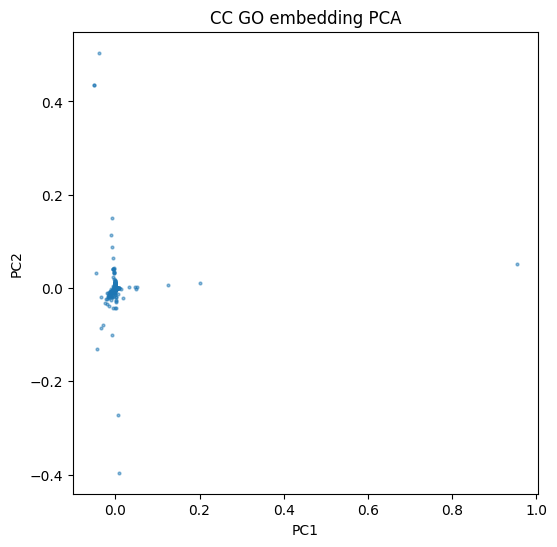

Explained variance ratio: [0.01564351 0.01564351]


In [25]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

emb_np = go_emb.detach().cpu().numpy()
pca = PCA(n_components=2)
xy = pca.fit_transform(emb_np)

plt.figure(figsize=(6, 6))
plt.scatter(xy[:, 0], xy[:, 1], s=4, alpha=0.5)
plt.title(f"{ONT.upper()} GO embedding PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

print("Explained variance ratio:", pca.explained_variance_ratio_)

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split

def build_edge_probe_dataset(go_emb, edge_pairs, rand_pairs):
    emb = go_emb.detach().cpu().numpy()
    X = []
    y = []

    for i, j in edge_pairs:
        X.append(np.concatenate([emb[i], emb[j], np.abs(emb[i] - emb[j]), emb[i] * emb[j]]))
        y.append(1)

    for i, j in rand_pairs:
        X.append(np.concatenate([emb[i], emb[j], np.abs(emb[i] - emb[j]), emb[i] * emb[j]]))
        y.append(0)

    X = np.array(X)
    y = np.array(y)
    return X, y

X_probe, y_probe = build_edge_probe_dataset(go_emb, edge_pairs, rand_pairs)

X_train, X_test, y_train, y_test = train_test_split(
    X_probe, y_probe, test_size=0.2, random_state=42, stratify=y_probe
)

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)
pred = clf.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, pred)
print("Edge probe ROC-AUC:", auc)

Edge probe ROC-AUC: 0.6399208704253214


In [27]:
def build_term_frequency(data):
    terms = data["terms"]
    term2idx = data["term2idx"]
    train_df = data["train_df"]

    counts = {g: 0 for g in terms}
    for anns in train_df["prop_annotations"]:
        for g in anns:
            if g in term2idx:
                counts[g] += 1

    freq = np.array([counts[g] for g in terms], dtype=np.int64)
    return counts, freq

counts, freq = build_term_frequency(data)

freq_df = pd.DataFrame({
    "go_id": terms,
    "freq": freq
}).sort_values("freq", ascending=False)

freq_df.head(), freq_df.tail()

(           go_id   freq
 2887  GO:0110165  51052
 2886  GO:0005622  40099
 2885  GO:0043226  34880
 2884  GO:0043229  33379
 2883  GO:0043227  31986,
           go_id  freq
 968  GO:0045244     0
 50   GO:0017086     0
 167  GO:0070514     0
 52   GO:0030095     0
 124  GO:0044184     0)

In [28]:
HEAD_THR = 100
TAIL_THR = 30

bucket = []
for f in freq:
    if f >= HEAD_THR:
        bucket.append("head")
    elif f < TAIL_THR:
        bucket.append("tail")
    else:
        bucket.append("mid")

bucket = np.array(bucket)

bucket_df = pd.DataFrame({
    "go_id": terms,
    "freq": freq,
    "bucket": bucket
})

bucket_df["bucket"].value_counts()

bucket
tail    2167
head     402
mid      319
Name: count, dtype: int64

In [29]:
emb_cpu = go_emb.detach().cpu()
norms = emb_cpu.norm(dim=1).numpy()

norm_df = pd.DataFrame({
    "go_id": terms,
    "freq": freq,
    "bucket": bucket,
    "norm": norms
})

print(norm_df.groupby("bucket")["norm"].agg(["mean", "std", "min", "max", "count"]))

corr_pearson = np.corrcoef(freq, norms)[0, 1]
corr_spearman = pd.Series(freq).corr(pd.Series(norms), method="spearman")

print("Pearson(freq, norm) =", corr_pearson)
print("Spearman(freq, norm) =", corr_spearman)

            mean       std           min       max  count
bucket                                                   
head    0.008086  0.015866  3.393389e-08  0.162474    402
mid     0.019170  0.056569  2.357899e-09  0.865278    319
tail    0.045612  0.163962  5.762927e-09  0.991913   2167
Pearson(freq, norm) = -0.026954964747800386
Spearman(freq, norm) = 0.05352939289435678


In [30]:
def collect_edge_pairs_by_bucket(terms, parents, term2idx, bucket_map):
    pairs_by_bucket = {"head": [], "mid": [], "tail": []}

    for child in terms:
        b = bucket_map[child]
        for p in parents[child]:
            pairs_by_bucket[b].append((term2idx[child], term2idx[p]))

    return pairs_by_bucket

bucket_map = {g: b for g, b in zip(terms, bucket)}
pairs_by_bucket = collect_edge_pairs_by_bucket(terms, parents, term2idx, bucket_map)

def pair_cosines(go_emb, pairs):
    emb = torch.nn.functional.normalize(go_emb.detach().cpu(), dim=1)
    vals = []
    for i, j in pairs:
        vals.append((emb[i] * emb[j]).sum().item())
    return np.array(vals)

rows = []
for b in ["head", "mid", "tail"]:
    pairs = pairs_by_bucket[b]
    if len(pairs) == 0:
        continue
    vals = pair_cosines(go_emb, pairs)
    rows.append({
        "bucket": b,
        "edge_cos_mean": vals.mean(),
        "edge_cos_std": vals.std(),
        "n_edges": len(vals)
    })

pd.DataFrame(rows)

,bucket,edge_cos_mean,edge_cos_std,n_edges
0,head,0.662270,0.303320,453
1,mid,0.728552,0.311666,389
2,tail,0.785039,0.290920,2529


In [31]:
def collect_ancestor_pairs_by_bucket(terms, ancestor_map, term2idx, bucket_map):
    pairs_by_bucket = {"head": [], "mid": [], "tail": []}

    for child in terms:
        b = bucket_map[child]
        for a in ancestor_map[child]:
            pairs_by_bucket[b].append((term2idx[child], term2idx[a]))

    return pairs_by_bucket

anc_pairs_by_bucket = collect_ancestor_pairs_by_bucket(terms, ancestor_map, term2idx, bucket_map)

rows = []
for b in ["head", "mid", "tail"]:
    pairs = anc_pairs_by_bucket[b]
    if len(pairs) == 0:
        continue
    vals = pair_cosines(go_emb, pairs)
    rows.append({
        "bucket": b,
        "ancestor_cos_mean": vals.mean(),
        "ancestor_cos_std": vals.std(),
        "n_pairs": len(vals)
    })

pd.DataFrame(rows)

,bucket,ancestor_cos_mean,ancestor_cos_std,n_pairs
0,head,0.496403,0.297879,1509
1,mid,0.555172,0.317308,1339
2,tail,0.624267,0.317259,8221


In [32]:
def nearest_neighbor_recall_by_bucket(go_emb, terms, parents, children, ancestor_map, term2idx, bucket_map, target_bucket="tail", k_list=[5, 10, 20]):
    emb = torch.nn.functional.normalize(go_emb.detach().cpu(), dim=1)
    sim = emb @ emb.T
    sim.fill_diagonal_(-1e9)

    results = []

    for k in k_list:
        topk = torch.topk(sim, k=k, dim=1).indices.numpy()

        edge_hits = []
        anc_hits = []

        for i, g in enumerate(terms):
            if bucket_map[g] != target_bucket:
                continue

            true_edge = set(term2idx[x] for x in parents[g] | children[g] if x in term2idx)
            true_anc = set(term2idx[x] for x in ancestor_map[g] if x in term2idx)

            pred = set(topk[i].tolist())

            if len(true_edge) > 0:
                edge_hits.append(len(pred & true_edge) / min(k, len(true_edge)))
            if len(true_anc) > 0:
                anc_hits.append(len(pred & true_anc) / min(k, len(true_anc)))

        results.append({
            "bucket": target_bucket,
            "k": k,
            "edge_recall_mean": np.mean(edge_hits) if edge_hits else 0.0,
            "ancestor_recall_mean": np.mean(anc_hits) if anc_hits else 0.0,
            "n_terms": sum(bucket_map[g] == target_bucket for g in terms)
        })

    return pd.DataFrame(results)

tail_nn_df = nearest_neighbor_recall_by_bucket(
    go_emb, terms, parents, children, ancestor_map, term2idx, bucket_map,
    target_bucket="tail", k_list=[5, 10, 20]
)

mid_nn_df = nearest_neighbor_recall_by_bucket(
    go_emb, terms, parents, children, ancestor_map, term2idx, bucket_map,
    target_bucket="mid", k_list=[5, 10, 20]
)

head_nn_df = nearest_neighbor_recall_by_bucket(
    go_emb, terms, parents, children, ancestor_map, term2idx, bucket_map,
    target_bucket="head", k_list=[5, 10, 20]
)

pd.concat([head_nn_df, mid_nn_df, tail_nn_df], axis=0)

,bucket,k,edge_recall_mean,ancestor_recall_mean,n_terms
0,head,5,0.361360,0.076190,402
1,head,10,0.422805,0.091006,402
2,head,20,0.525497,0.136122,402
0,mid,5,0.400575,0.108046,319
1,mid,10,0.503209,0.136333,319
2,mid,20,0.610348,0.187270,319
0,tail,5,0.317497,0.108553,2167
1,tail,10,0.426976,0.145549,2167
2,tail,20,0.530110,0.207894,2167


In [33]:
def neighbor_bucket_composition(go_emb, terms, bucket_map, k=10):
    emb = torch.nn.functional.normalize(go_emb.detach().cpu(), dim=1)
    sim = emb @ emb.T
    sim.fill_diagonal_(-1e9)

    topk = torch.topk(sim, k=k, dim=1).indices.numpy()

    rows = []
    for i, g in enumerate(terms):
        src_bucket = bucket_map[g]
        neighbor_buckets = [bucket_map[terms[j]] for j in topk[i]]

        rows.append({
            "src_bucket": src_bucket,
            "head_frac": np.mean([x == "head" for x in neighbor_buckets]),
            "mid_frac": np.mean([x == "mid" for x in neighbor_buckets]),
            "tail_frac": np.mean([x == "tail" for x in neighbor_buckets]),
        })

    df = pd.DataFrame(rows)
    return df.groupby("src_bucket")[["head_frac", "mid_frac", "tail_frac"]].mean()

neighbor_bucket_composition(go_emb, terms, bucket_map, k=10)

,head_frac,mid_frac,tail_frac
src_bucket,,,
head,0.210448,0.139303,0.650249
mid,0.164577,0.159875,0.675549
tail,0.107799,0.097000,0.795201


In [34]:
def average_knn_cosine(go_emb, k=10):
    emb = torch.nn.functional.normalize(go_emb.detach().cpu(), dim=1)
    sim = emb @ emb.T
    sim.fill_diagonal_(-1e9)

    vals, idx = torch.topk(sim, k=k, dim=1)
    return vals.mean(dim=1).numpy()

knn10 = average_knn_cosine(go_emb, k=10)

density_df = pd.DataFrame({
    "go_id": terms,
    "freq": freq,
    "bucket": bucket,
    "knn10_cos": knn10
})

print(density_df.groupby("bucket")["knn10_cos"].agg(["mean", "std", "min", "max", "count"]))

print("Spearman(freq, knn10_cos) =", pd.Series(freq).corr(pd.Series(knn10), method="spearman"))

            mean       std       min  max  count
bucket                                          
head    0.964408  0.048847  0.706350  1.0    402
mid     0.962522  0.074519  0.521308  1.0    319
tail    0.971064  0.070433  0.275829  1.0   2167
Spearman(freq, knn10_cos) = -0.19343086775637694


In [35]:
def sample_by_ancestor_distance_for_bucket(terms, parents, term2idx, bucket_map, target_bucket="tail", max_dist=5, per_dist=1000, seed=42):
    rng = np.random.default_rng(seed)
    buckets = {d: [] for d in range(1, max_dist + 1)}

    nodes = [g for g in terms if bucket_map[g] == target_bucket]

    def get_ancestors_local(node):
        visited = set()
        stack = list(parents[node])
        while stack:
            x = stack.pop()
            if x not in visited:
                visited.add(x)
                stack.extend(parents[x])
        return visited

    def shortest_ancestor_distance(start, target, max_depth=10):
        if start == target:
            return 0
        q = deque([(start, 0)])
        visited = {start}
        while q:
            node, dist = q.popleft()
            if dist >= max_depth:
                continue
            for p in parents[node]:
                if p == target:
                    return dist + 1
                if p not in visited:
                    visited.add(p)
                    q.append((p, dist + 1))
        return None

    for _ in range(300000):
        if len(nodes) == 0:
            break
        child = rng.choice(nodes)
        ancs = list(get_ancestors_local(child))
        if not ancs:
            continue
        a = rng.choice(ancs)
        d = shortest_ancestor_distance(child, a, max_depth=max_dist)
        if d is not None and 1 <= d <= max_dist and len(buckets[d]) < per_dist:
            buckets[d].append((term2idx[child], term2idx[a]))
        if all(len(buckets[d]) >= per_dist for d in buckets):
            break

    rows = []
    for d, pairs in buckets.items():
        if len(pairs) > 0:
            vals = pair_cosines(go_emb, pairs)
            rows.append({
                "bucket": target_bucket,
                "graph_dist": d,
                "mean_cos": vals.mean(),
                "std_cos": vals.std(),
                "n": len(vals)
            })
    return pd.DataFrame(rows)

tail_dist_df = sample_by_ancestor_distance_for_bucket(
    terms, parents, term2idx, bucket_map,
    target_bucket="tail", max_dist=5, per_dist=1000
)

mid_dist_df = sample_by_ancestor_distance_for_bucket(
    terms, parents, term2idx, bucket_map,
    target_bucket="mid", max_dist=5, per_dist=1000
)

head_dist_df = sample_by_ancestor_distance_for_bucket(
    terms, parents, term2idx, bucket_map,
    target_bucket="head", max_dist=5, per_dist=1000
)

pd.concat([head_dist_df, mid_dist_df, tail_dist_df], axis=0)

,bucket,graph_dist,mean_cos,std_cos,n
0,head,1,0.566811,0.308103,1000
1,head,2,0.493226,0.269165,1000
2,head,3,0.394944,0.231439,1000
3,head,4,0.327677,0.204474,1000
4,head,5,0.304331,0.202997,1000
0,mid,1,0.612262,0.340490,1000
1,mid,2,0.510009,0.305558,1000
2,mid,3,0.457958,0.271835,1000
3,mid,4,0.408640,0.259713,1000
4,mid,5,0.354672,0.252414,1000


In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split

X = go_emb.detach().cpu().numpy()
y_tail = (bucket == "tail").astype(np.int64)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_tail, test_size=0.2, random_state=42, stratify=y_tail
)

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)
pred = clf.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, pred)
print("Tail-vs-not probe ROC-AUC:", auc)

Tail-vs-not probe ROC-AUC: 0.5249055939580133


In [37]:
import numpy as np
import torch
import pandas as pd
from pathlib import Path
from collections import defaultdict
from tqdm import tqdm

OBO_PATH = Path("data/go-basic.obo")

def parse_go_obo(obo_path):
    parents = defaultdict(set)
    children = defaultdict(set)

    current_id = None

    with open(obo_path, "r") as f:
        for line in f:
            line = line.strip()

            if line == "[Term]":
                current_id = None
                continue

            if line.startswith("id: GO:"):
                current_id = line.split("id: ")[1]

            elif line.startswith("is_a: GO:") and current_id:
                p = line.split("is_a: ")[1].split(" ! ")[0]
                parents[current_id].add(p)
                children[p].add(current_id)

    return parents, children


parents_all, children_all = parse_go_obo(OBO_PATH)


def pair_cos(go_emb, pairs):
    emb = torch.nn.functional.normalize(go_emb, dim=1)
    vals = [(emb[i] * emb[j]).sum().item() for i, j in pairs]
    return np.array(vals)


def nearest_neighbor_recall(go_emb, parents, term2idx, k=10):
    emb = torch.nn.functional.normalize(go_emb, dim=1)
    sim = emb @ emb.T
    sim.fill_diagonal_(-1e9)

    topk = torch.topk(sim, k=k, dim=1).indices

    recalls = []

    for i in range(len(topk)):
        term = list(term2idx.keys())[i]

        true = set(term2idx[p] for p in parents[term] if p in term2idx)
        pred = set(topk[i].tolist())

        if len(true) > 0:
            recalls.append(len(true & pred) / min(k, len(true)))

    return np.mean(recalls)


def evaluate_ontology(ont):
    print(f"\n===== {ont.upper()} =====")

    if ont == "ec":
        data = load_ec_for_analysis()
        terms = data["terms"]
        term2idx = data["term2idx"]
        K = data["K"]
        go_emb = data["go_emb"].detach().cpu()

        parents = build_ec_parents(terms, term2idx)

    else:
        data = load_ontology(ont)
        terms = data["terms"]
        term2idx = data["term2idx"]
        K = data["K"]

        go_emb = load_go_emb(ont, K)
        go_emb = go_emb.detach().cpu()

        parents = {
            g: set(p for p in parents_all[g] if p in term2idx)
            for g in terms
        }

    print("K =", K)
    print("Embedding shape =", tuple(go_emb.shape))

    edge_pairs = []
    for g in terms:
        for p in parents.get(g, []):
            edge_pairs.append((term2idx[g], term2idx[p]))

    if len(edge_pairs) == 0:
        edge_cos_mean = np.nan
        rand_cos_mean = np.nan
        print("No hierarchy edges found.")
    else:
        edge_cos = pair_cos(go_emb, edge_pairs)

        rand_pairs = []
        rng = np.random.default_rng(42)

        while len(rand_pairs) < len(edge_pairs):
            i = int(rng.integers(0, K))
            j = int(rng.integers(0, K))
            if i != j:
                rand_pairs.append((i, j))

        rand_cos = pair_cos(go_emb, rand_pairs)

        edge_cos_mean = edge_cos.mean()
        rand_cos_mean = rand_cos.mean()

        print(f"Edge cosine mean: {edge_cos_mean:.4f}")
        print(f"Random cosine mean: {rand_cos_mean:.4f}")

    nn_recall = nearest_neighbor_recall(go_emb, parents, term2idx, k=10)
    print(f"NN Recall@10: {nn_recall:.4f}")

    sim = torch.nn.functional.normalize(go_emb, dim=1) @ \
          torch.nn.functional.normalize(go_emb, dim=1).T

    sim.fill_diagonal_(-1e9)
    knn = torch.topk(sim, k=10, dim=1).values.mean().item()

    print(f"KNN cosine mean: {knn:.4f}")

    prop = propagation_strength(go_emb)
    ent = graph_entropy(go_emb)
    rank = effective_rank(go_emb)
    div = neighbor_diversity(go_emb)

    print(f"Propagation strength: {prop:.4f}")
    print(f"Graph entropy: {ent:.4f}")
    print(f"Effective rank: {rank:.2f}")
    print(f"Neighbor diversity: {div:.4f}")

    hc = hierarchical_consistency(go_emb, parents, term2idx)
    dm = distance_monotonicity(go_emb, parents, term2idx)
    anis = local_anisotropy(go_emb)

    print(f"Hierarchical consistency (↓ better): {hc:.4f}")
    print(f"Distance monotonicity (↑ better): {dm:.4f}")
    print(f"Local anisotropy (↑ better): {anis:.4f}")

    return {
        "ontology": ont,
        "K": K,
        "edge_cos": edge_cos_mean,
        "rand_cos": rand_cos_mean,
        "nn_recall": nn_recall,
        "knn_cos": knn,
        "propagation_strength": prop,
        "graph_entropy": ent,
        "effective_rank": rank,
        "neighbor_diversity": div,
        "hierarchical_consistency": hc,
        "distance_monotonicity": dm,
        "local_anisotropy": anis,
    }

def propagation_strength(go_emb, k=10):
    emb = torch.nn.functional.normalize(go_emb, dim=1)
    sim = emb @ emb.T
    sim.fill_diagonal_(-1e9)

    topk_val, topk_idx = torch.topk(sim, k=k, dim=1)

    A = torch.zeros_like(sim)
    A.scatter_(1, topk_idx, topk_val)
    A = torch.softmax(A / 0.1, dim=1)

    s = torch.rand(len(go_emb), device=go_emb.device)

    neigh = A @ s
    delta = (neigh - s).abs().mean().item()

    return delta

def graph_entropy(go_emb, k=10):
    emb = torch.nn.functional.normalize(go_emb, dim=1)
    sim = emb @ emb.T
    sim.fill_diagonal_(-1e9)

    topk_val, topk_idx = torch.topk(sim, k=k, dim=1)

    A = torch.zeros_like(sim)
    A.scatter_(1, topk_idx, topk_val)
    A = torch.softmax(A / 0.1, dim=1)

    entropy = -(A * torch.log(A + 1e-8)).sum(dim=1).mean().item()
    return entropy

def effective_rank(go_emb):
    emb = torch.nn.functional.normalize(go_emb, dim=1)
    cov = emb.T @ emb / emb.shape[0]

    s = torch.linalg.svdvals(cov)
    s = s / s.sum()

    entropy = -(s * torch.log(s + 1e-8)).sum()
    rank = torch.exp(entropy).item()

    return rank

def neighbor_diversity(go_emb, k=10):
    emb = torch.nn.functional.normalize(go_emb, dim=1)
    sim = emb @ emb.T
    sim.fill_diagonal_(-1e9)

    topk_idx = torch.topk(sim, k=k, dim=1).indices

    diversities = []

    for i in range(len(go_emb)):
        neigh = emb[topk_idx[i]]
        center = emb[i]

        cos = (neigh @ center).mean().item()
        diversities.append(1 - cos)

    return np.mean(diversities)

def hierarchical_consistency(go_emb, parents, term2idx):
    emb = torch.nn.functional.normalize(go_emb, dim=1)

    diffs = []

    for child in parents:
        if child not in term2idx:
            continue

        c_idx = term2idx[child]

        for p in parents[child]:
            if p not in term2idx:
                continue

            p_idx = term2idx[p]

            diff = emb[c_idx] - emb[p_idx]
            diffs.append(diff.numpy())

    diffs = np.stack(diffs)

    var = np.var(diffs, axis=0).mean()
    return var

def distance_monotonicity(go_emb, parents, term2idx, max_depth=3):
    from collections import deque

    emb = torch.nn.functional.normalize(go_emb, dim=1)

    pairs = []

    for root in term2idx:
        queue = deque([(root, 0)])

        visited = set()

        while queue:
            node, depth = queue.popleft()
            if depth > max_depth:
                continue

            if node not in term2idx:
                continue

            i = term2idx[root]
            j = term2idx[node]

            dist = 1 - (emb[i] @ emb[j]).item()

            pairs.append((depth, dist))

            for p in parents.get(node, []):
                if p not in visited:
                    visited.add(p)
                    queue.append((p, depth + 1))

    depths = np.array([x[0] for x in pairs])
    dists = np.array([x[1] for x in pairs])

    corr = np.corrcoef(depths, dists)[0,1]
    return corr

def local_anisotropy(go_emb, k=10):
    emb = torch.nn.functional.normalize(go_emb, dim=1)
    sim = emb @ emb.T
    sim.fill_diagonal_(-1e9)

    topk_idx = torch.topk(sim, k=k, dim=1).indices

    anis = []

    for i in range(len(go_emb)):
        neigh = emb[topk_idx[i]]

        cov = neigh.T @ neigh / k
        eigvals = torch.linalg.eigvals(cov).real

        ratio = eigvals.max() / (eigvals.sum() + 1e-8)
        anis.append(ratio.item())

    return np.mean(anis)

def load_ec_for_analysis():
    data = torch.load("data/ec_dataset.pt")

    terms = list(data["ec2idx"].keys())
    term2idx = data["ec2idx"]
    K = len(terms)

    ec_emb = np.load("data/ec_directed_spectral_emb.npy")
    go_emb = torch.tensor(ec_emb, dtype=torch.float32)

    assert go_emb.shape[0] == K, \
        f"EC embedding rows {go_emb.shape[0]} != EC K {K}"

    return {
        "terms": terms,
        "term2idx": term2idx,
        "K": K,
        "go_emb": go_emb
    }


def build_ec_parents(terms, term2idx):
    parents = {}
    for ec in terms:
        parts = ec.split(".")
        ps = set()
        for i in range(1, len(parts)):
            parent = ".".join(parts[:i])
            if parent in term2idx:
                ps.add(parent)
        parents[ec] = ps
    return parents



results = []
for ont in ["ec", "cc", "mf", "bp"]:
    results.append(evaluate_ontology(ont))

df = pd.DataFrame(results)

print("\n===== SUMMARY =====")
print(df)

df.to_csv("embedding_geometry_summary_with_ec.csv", index=False)
print("Saved: embedding_geometry_summary_with_ec.csv")


===== EC =====
K = 2131
Embedding shape = (2131, 64)
Edge cosine mean: 0.8903
Random cosine mean: 0.1457
NN Recall@10: 0.1369
KNN cosine mean: 0.9621
Propagation strength: 0.2589
Graph entropy: 2.3458
Effective rank: 15.78
Neighbor diversity: 0.0379
Hierarchical consistency (↓ better): 0.0034
Distance monotonicity (↑ better): 0.2413
Local anisotropy (↑ better): 0.9788

===== CC =====
K = 2888
Embedding shape = (2888, 64)
Edge cosine mean: 0.7620
Random cosine mean: 0.1581
NN Recall@10: 0.3636
KNN cosine mean: 0.9692
Propagation strength: 0.2550
Graph entropy: 2.4312
Effective rank: 27.34
Neighbor diversity: 0.0308
Hierarchical consistency (↓ better): 0.0073
Distance monotonicity (↑ better): 0.5433
Local anisotropy (↑ better): 0.9714

===== MF =====
K = 7114
Embedding shape = (7114, 256)
Edge cosine mean: 0.8651
Random cosine mean: 0.0255
NN Recall@10: 0.4365
KNN cosine mean: 0.9544
Propagation strength: 0.2587
Graph entropy: 2.6841
Effective rank: 122.46
Neighbor diversity: 0.0456
Hie